# Residual catalog

TxNova recovers unannotated spliced residual loci from BAM files you already have. Control and treat labels are optional.

This notebook does not rerun `txnova`. It reads bundled TSVs from one GSE221720 run.

`RSDL.n` IDs belong to that run. They are not gene names.

```bash
pip install txnova pandas matplotlib
```

**Data.** `docs/tutorials/data/` next to this notebook (`SOURCE.txt`).
If you still have FASTQ, start with {doc}`t_prepare_bams`. Then {doc}`../quickstart`.
Columns: {doc}`../outputs`.


In [1]:
%matplotlib inline

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

HERE = Path("data")
if not (HERE / "residual.tsv").is_file():
    HERE = Path("docs/tutorials/data")

res = pd.read_csv(HERE / "residual.tsv", sep="\t")
final = pd.read_csv(HERE / "candidates.tsv", sep="\t")
unnamed = pd.read_csv(HERE / "candidates.unnamed.tsv", sep="\t")
print("residual", len(res), "≥2 junctions", int((res.n_junctions >= 2).sum()))
print("contrast screen (bundled)", len(final), "unnamed", len(unnamed))


residual 214 ≥2 junctions 49
contrast screen (bundled) 13 unnamed 32


## 1. Catalog, then contrast

Most published bulk RNA-seq papers stop at annotated genes. Spliced reads outside GENCODE stay in the BAM. TxNova keeps CIGAR `N` junctions seen in at least two samples and missing from the annotation, clusters them into residual loci, and counts those loci with GENCODE.

You can run this with no `group` column. Contrast filters run only if the sheet has both `control` and `treat`.


## 2. Sample sheet without groups

Use at least two coordinate-sorted, indexed STAR or HISAT2 BAM files. Same aligner and strandedness. Omit `group`:

```text
sample_id	bam	strandedness
s1	/data/treat_1.bam	rf
s2	/data/treat_2.bam	rf
s3	/data/treat_3.bam	rf
s4	/data/treat_4.bam	rf
```

`txnova init` writes a sheet that includes `group`. Delete that column for a catalog-only run.

```bash
txnova init -c config.yaml --samples samples.tsv
# point genome.fasta / genome.annotation at the same build as the BAMs
# edit samples.tsv: drop group, fill bam paths and strandedness
txnova preflight -c config.yaml
txnova run -c config.yaml
```

Preflight accepts a sheet with no groups. DE runs only when you have at least two control and two treat samples.


## 3. Residual table

`candidates/residual.tsv` is the harvest table. Harvest is cohort-recurrent: a CIGAR `N` junction in at least two samples, missing from the annotation. The bundled file is from one GSE221720 run (four treated and four contralateral BAM files). That snapshot required treat recurrence because the sheet had groups; a sheet with no `group` column uses any two samples.

Structure gates are not applied to this file. `nearest_distance_bp` is the same-strand distance of the clipped locus (the 1 kb gate interval), not of the intron. The 200 nt harvest knife uses the intron span.


In [3]:
cat_sum = pd.DataFrame(
    {
        "set": ["all residual", "≥2 junctions", "≥3 exons"],
        "n": [
            len(res),
            int((res.n_junctions >= 2).sum()),
            int((res.n_exons >= 3).sum()),
        ],
    }
)
cat_sum


,set,n
0,all residual,214
1,≥2 junctions,49
2,≥3 exons,38


In [4]:
cols = [
    c
    for c in (
        "residual_id",
        "locus_coord",
        "n_junctions",
        "n_exons",
        "length_nt",
        "nearest_gene_name",
        "nearest_distance_bp",
        "treat_sum",
        "treat_n_detected",
        "cohort",
    )
    if c in res.columns
]
res.sort_values(["n_junctions", "treat_sum"], ascending=False)[cols].head(8)


,residual_id,locus_coord,n_junctions,n_exons,length_nt,nearest_gene_name,nearest_distance_bp,treat_sum,treat_n_detected,cohort
0,RSDL.1,chr6:22510224-22525679:+,10,5,2791,Gm67965,69944.0,126,4,shared
1,RSDL.2,chr17:44730868-44741645:+,10,4,4207,Gm65760,11222.0,124,4,shared
2,RSDL.3,GL456233.2:105707-134104:-,9,8,2526,NaN,NaN,1345,4,shared
3,RSDL.4,GL456233.2:251310-468997:+,9,8,2337,NaN,NaN,420,4,shared
4,RSDL.5,chr19:58121891-58131898:-,6,4,1097,Gm50287,37427.0,58,4,shared
5,RSDL.6,chr1:182835049-182843973:-,6,6,3075,Disp1,1004.0,28,3,shared
6,RSDL.7,chr1:10385123-10393856:+,6,3,2772,Gm70170,78792.0,23,4,shared
7,RSDL.8,chr1:171725805-171736058:+,5,4,5632,Gm10521,0.0,33,4,shared


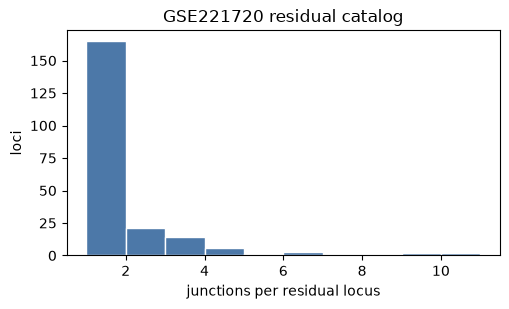

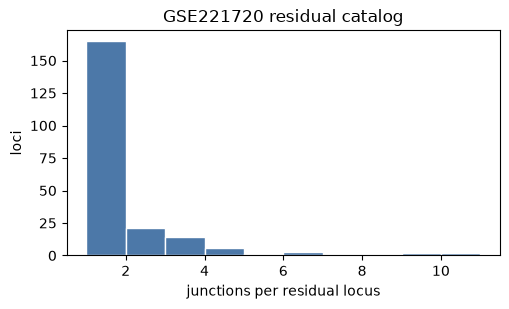

In [5]:
fig, ax = plt.subplots(figsize=(5.2, 3.2))
ax.hist(res.n_junctions, bins=range(1, int(res.n_junctions.max()) + 2), color="#4C78A8", edgecolor="white")
ax.set_xlabel("junctions per residual locus")
ax.set_ylabel("loci")
ax.set_title("GSE221720 residual catalog")
fig.tight_layout()
fig


On a run with no groups, `candidates/candidates.tsv` holds residuals that pass the structure gates (canonical splice, 1 kb neighbor distance, coverage valley, bridging reads, RepeatMasker). `unnamed` and `shared` are unused if there are no control samples.

If `candidates.tsv` is empty, every residual failed a structure gate. See {doc}`../faq`.


## 4. Optional contrast screen

If the sheet has both `control` and `treat`, TxNova splits structure-pass loci by TPM. The bundled `candidates.tsv` and `candidates.unnamed.tsv` are an older contrast snapshot of GSE221720. Their `RSDL` IDs do not match `residual.tsv`.

```text
sample_id	bam	group	strandedness
c1	/data/ctrl_1.bam	control	rf
c2	/data/ctrl_2.bam	control	rf
t1	/data/treat_1.bam	treat	rf
t2	/data/treat_2.bam	treat	rf
```

Current default contrast gates: control max TPM < 0.5, at least three treat samples at TPM ≥ 0.1, treat median ≥ 0.5, RepeatMasker < 0.1 when `rmsk_bed` is set. `de_status=low_count` means DESeq2 did not assign a padj (independent filtering).


In [6]:
screen = pd.DataFrame(
    {
        "table": ["catalog (residual.tsv)", "contrast screen (candidates.tsv)", "unnamed (control TPM)"],
        "n": [len(res), len(final), len(unnamed)],
        "multi_exon": [
            int((res.n_exons >= 3).sum()),
            int((final.n_exons >= 3).sum()),
            int((unnamed.n_exons >= 3).sum()),
        ],
    }
)
screen


,table,n,multi_exon
0,catalog (residual.tsv),214,38
1,contrast screen (candidates.tsv),13,1
2,unnamed (control TPM),32,2


In [7]:
show = [
    c
    for c in (
        "locus_id",
        "locus_coord",
        "n_exons",
        "length_nt",
        "nearest_gene_name",
        "nearest_distance_bp",
        "control_max_tpm",
        "treat_n_detected",
        "de_status",
    )
    if c in final.columns
]
final[show].head(8)


,locus_id,locus_coord,n_exons,length_nt,nearest_gene_name,nearest_distance_bp,control_max_tpm,treat_n_detected,de_status
0,RSDL.15,chr16:91760738-91761524:-,2,504,Gm60892,16199,0.000000,3,low_count
1,RSDL.19,chr4:47081200-47086722:+,2,1333,Galnt12,5182,0.916642,4,low_count
2,RSDL.22,chr9:79344291-79349547:-,2,301,Gm10635,1679,0.000000,2,low_count
3,RSDL.25,chr2:57754655-57755523:-,2,280,Gm74570,31343,0.000000,3,low_count
4,RSDL.31,chr11:118262483-118265065:-,2,842,Lgals3bp,15650,0.362792,3,low_count
5,RSDL.4,chr4:133241212-133245586:-,3,295,Nudc,13494,0.993471,2,low_count
6,RSDL.46,chr7:141376282-141377381:-,2,341,Tollip,51168,0.000000,2,low_count
7,RSDL.47,chr8:122194578-122195251:+,2,458,Gm63857,14800,0.000000,3,low_count


- **Catalog** (`residual.tsv`): residual loci from harvest.
- **Contrast screen** (`candidates.tsv` when both groups are set): treat-detected, control-silent subset.
- **Unnamed**: structure-pass and also present in control.

If you add `group` after a catalog run, the sample sheet changes and leak and residual run again:

```bash
txnova run -c config.yaml
```


## 5. What to report

Describe the catalog as cohort-recurrent unannotated splices clustered into residual loci and counted with GENCODE. If you used a contrast, state the TPM and RepeatMasker gates and report `wald` or `low_count`.

Pin the version (`txnova==0.1.7`). Do not report residual counts as new genes.

Next: {doc}`t_gse221720_rank_and_fold`, {doc}`fold_viewer`, {doc}`../configuration`.
